<a href="https://colab.research.google.com/github/DevNova11/EDA2026/blob/main/EXP5_04.08.2026/Multivariate_Bi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 2. Load the dataset and Display First and Last 3 rows of the dataset
df = pd.read_csv("/content/WineQT.csv")
print(df.head(3))
print(df.tail(3))

# 3. Check the data types of each column
df.dtypes

# 4. Get a concise summary of the DataFrame
print(df.info())

# 5. Find the descriptive Statistics of the entire dataset
print(df.describe())

# Check for missing values
print(pd.isna(df).sum())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [15]:
# 6. compute the measure of central tendency of the quality column.

mean_quality = df["quality"].mean()
median_quality = df["quality"].median()
mode_quality = df["quality"].mode()
print(f"Mean of quality: {mean_quality}")
print(f"Median of quality: {median_quality}")
print(f"Mode of quality: {mode_quality.tolist()}")

Mean of quality: 5.657042869641295
Median of quality: 6.0
Mode of quality: [5]


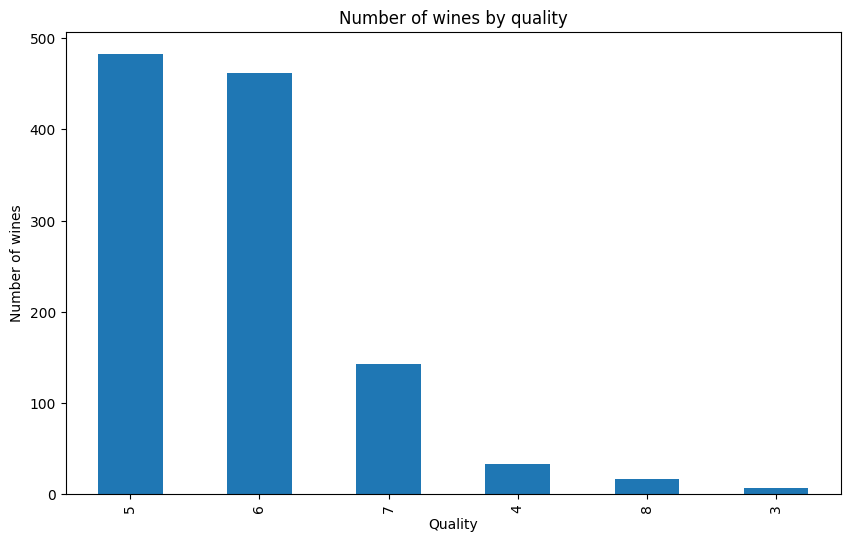

In [16]:
# 7. Plot the distribution of 'quality'
df['quality'].value_counts().nlargest(30).plot(kind='bar', figsize=(10,6))
plt.title("Number of wines by quality")
plt.ylabel('Number of wines')
plt.xlabel('Quality')
plt.show()

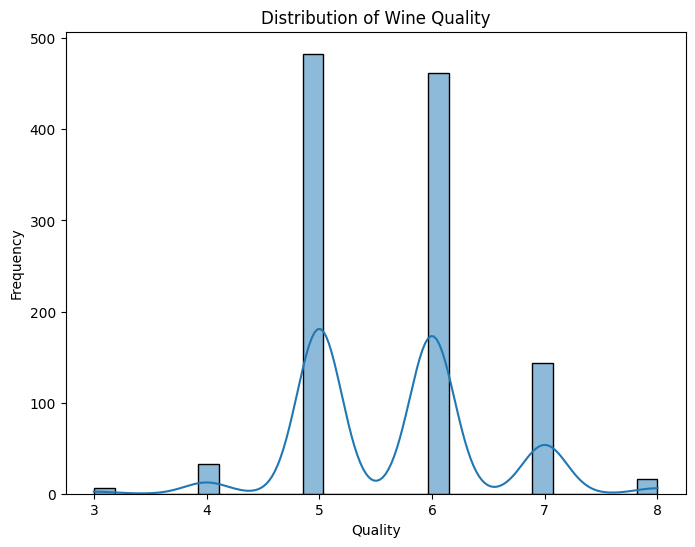

In [17]:
# 8. Distribution plot for 'quality'
plt.figure(figsize=(8,6))
sns.histplot(df['quality'], kde=True)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.show()

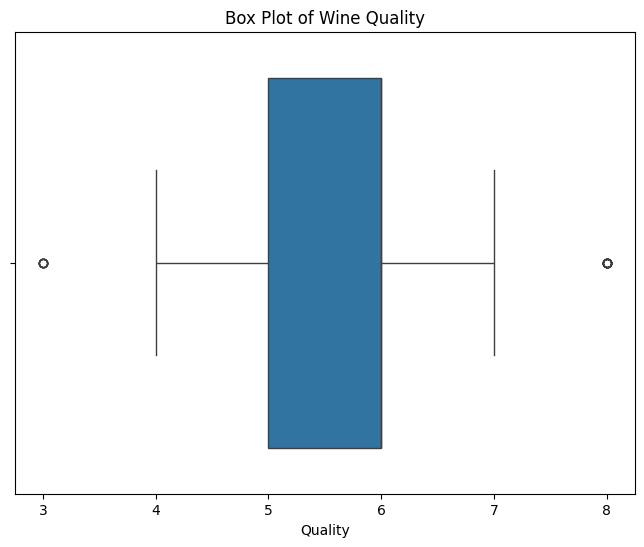

In [18]:
# Boxplot for 'quality'
plt.figure(figsize=(8,6))
sns.boxplot(x="quality", data=df)
plt.title('Box Plot of Wine Quality')
plt.xlabel('Quality')
plt.show()

## Multivariate Analysis

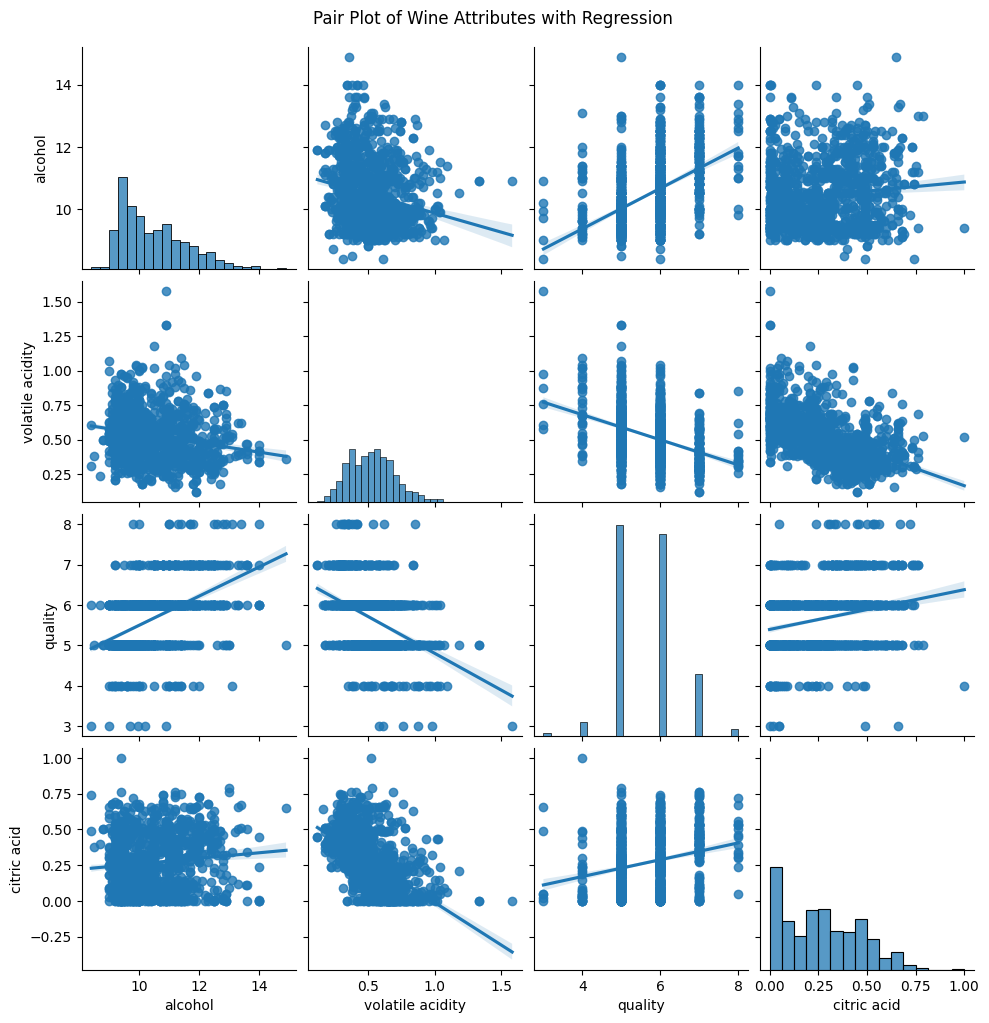

In [19]:
# 1. Pair plot with plot type regression for selected variables
sns.pairplot(df, vars=['alcohol', 'volatile acidity', 'quality', 'citric acid'], kind="reg")
plt.suptitle('Pair Plot of Wine Attributes with Regression', y=1.02)
plt.show()

### Correlation Analysis

In [20]:
# 3. Calculate the correlation coefficient for 'quality' and 'alcohol'
from scipy import stats

corr_qa = stats.pearsonr(df["quality"], df["alcohol"])
print(f"Correlation between Quality and Alcohol:")
print(f"  p-value:\t{corr_qa[1]:.3e}")
print(f"  cor:\t\t{corr_qa[0]:.3f}")

# To find the correlation among the entire numerical records
# using pearson method
correlation_matrix = df.corr(method='pearson', numeric_only=True)
print("\nCorrelation Matrix for all numerical columns:")
print(correlation_matrix)

Correlation between Quality and Alcohol:
  p-value:	1.925e-68
  cor:		0.485

Correlation Matrix for all numerical columns:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970  

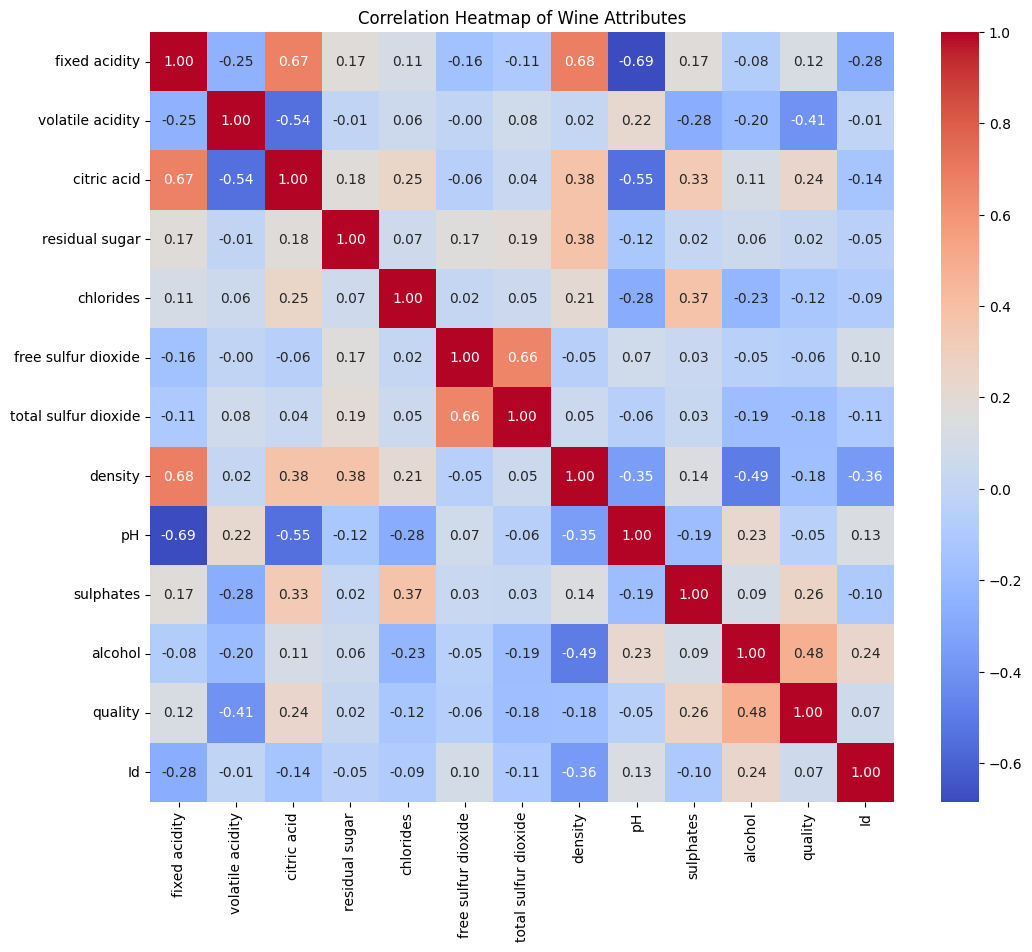

In [21]:
# 5. Visualize this correlation analysis using a heatmap.
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wine Attributes')
plt.show()

## Bivariate Analysis

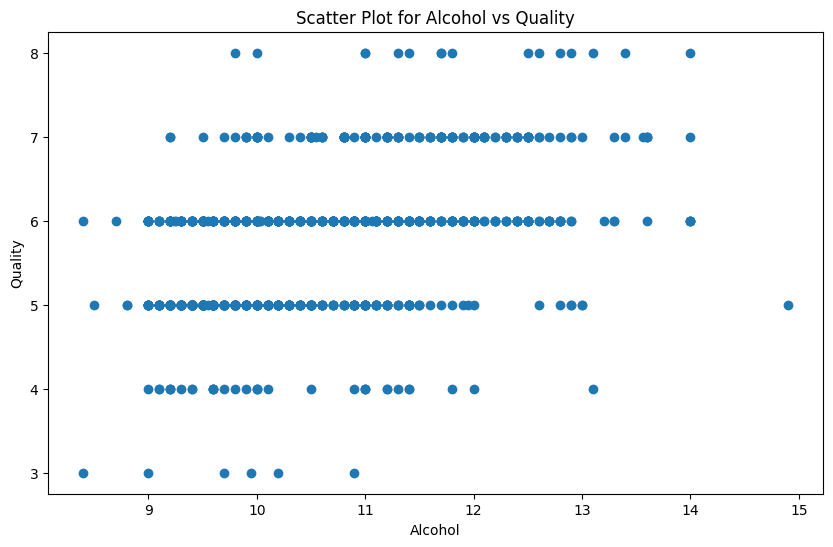

In [22]:
# 1. Plot the relationship between 'alcohol' and 'quality'
plt.figure(figsize=(10, 6))
plt.scatter(df["alcohol"], df["quality"])
plt.title("Scatter Plot for Alcohol vs Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.show()

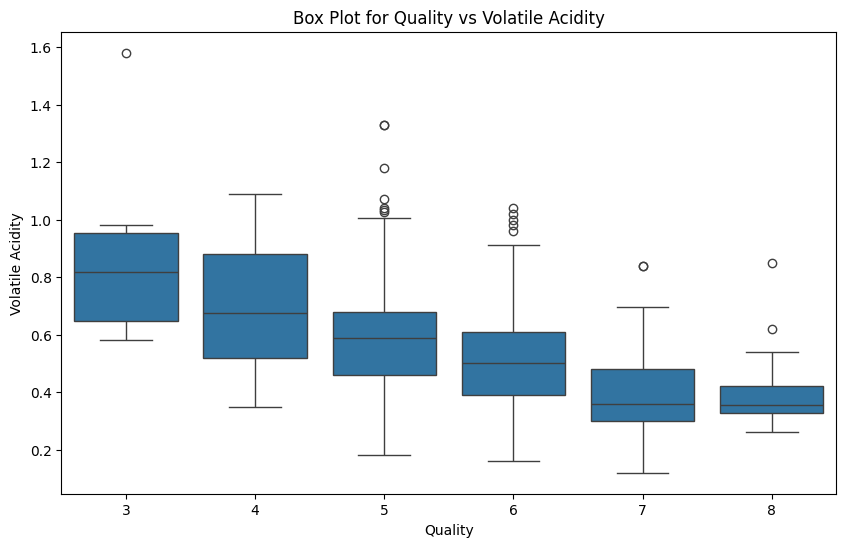

In [23]:
# 2. Draw a box plot between 'quality' and 'volatile acidity'
plt.figure(figsize=(10, 6))
sns.boxplot(x="quality", y="volatile acidity", data=df)
plt.title("Box Plot for Quality vs Volatile Acidity")
plt.xlabel("Quality")
plt.ylabel("Volatile Acidity")
plt.show()

### Bivariate Box Plot: Quality vs Alcohol


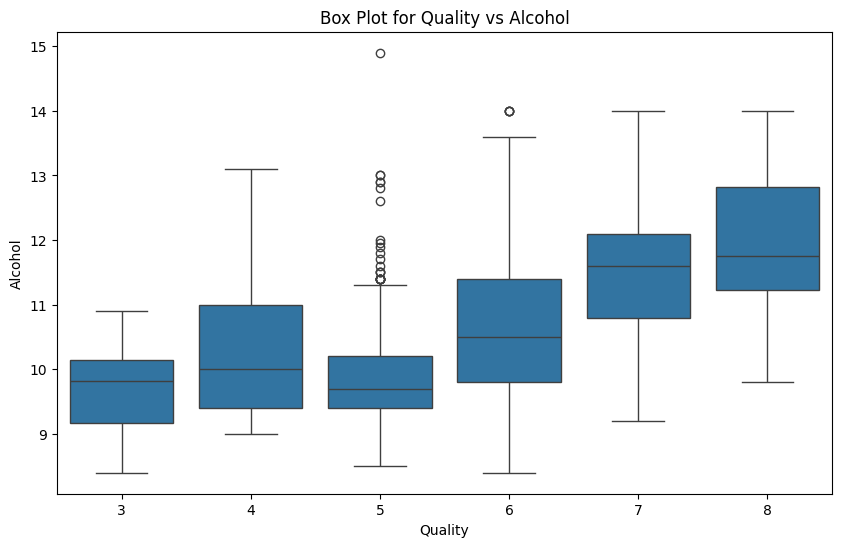

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="quality", y="alcohol", data=df)
plt.title("Box Plot for Quality vs Alcohol")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()


## Multivariate Analysis

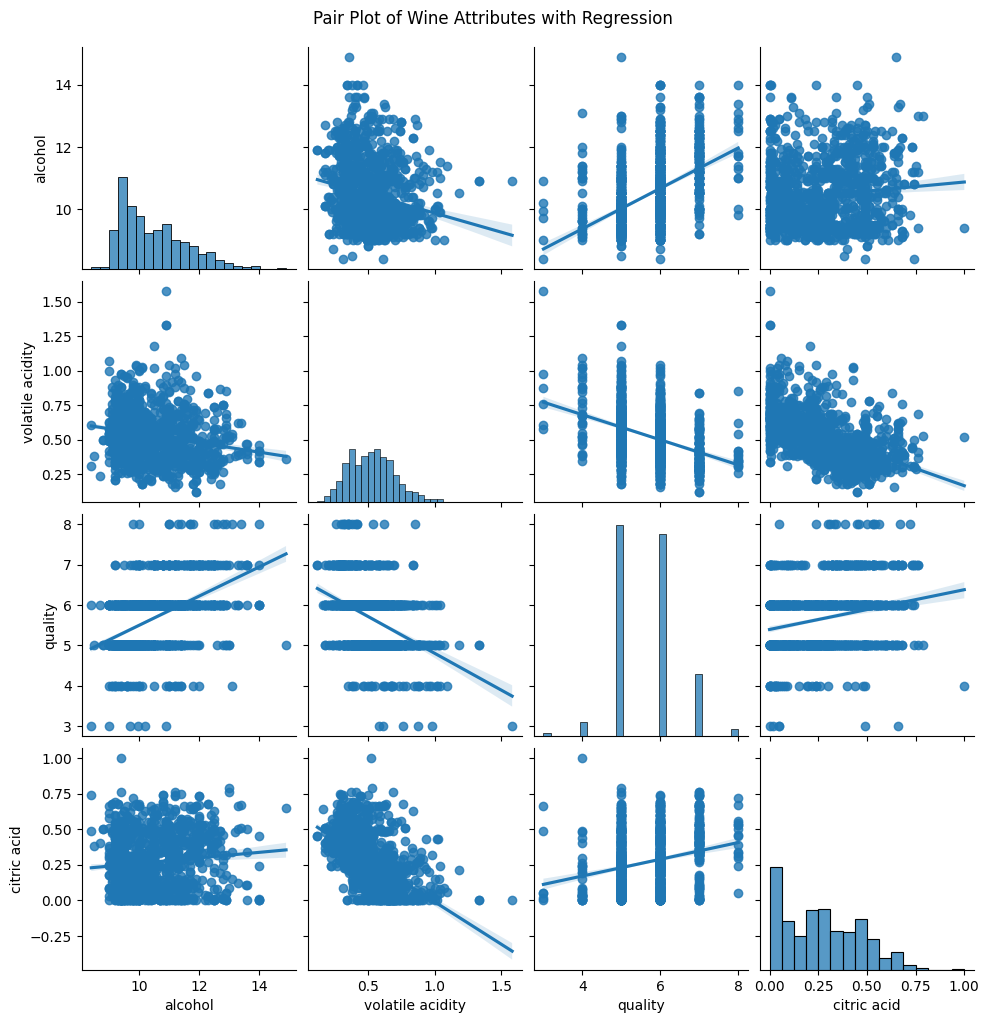

In [24]:
# 1. Pair plot with plot type regression for selected variables
sns.pairplot(df, vars=['alcohol', 'volatile acidity', 'quality', 'citric acid'], kind="reg")
plt.suptitle('Pair Plot of Wine Attributes with Regression', y=1.02)
plt.show()

### Multivariate Pair Plot with Hue


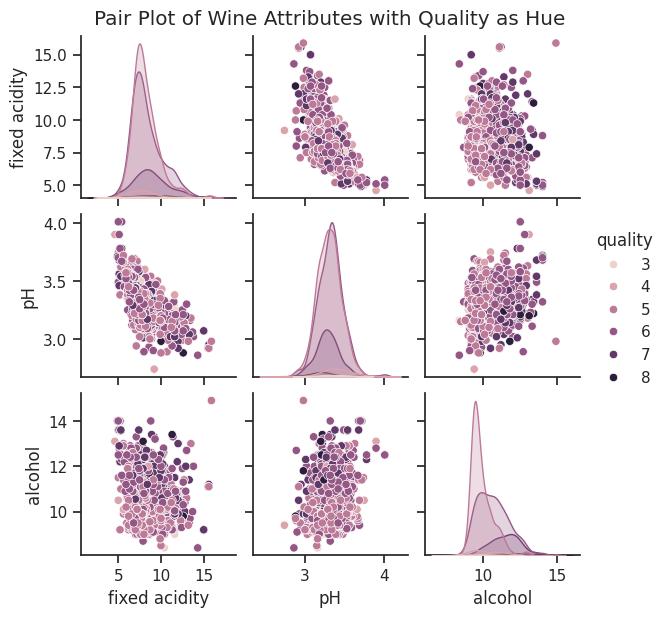

In [28]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['fixed acidity', 'pH', 'alcohol'], hue="quality")
plt.suptitle('Pair Plot of Wine Attributes with Quality as Hue', y=1.02)
plt.show()


### Correlation Analysis

In [25]:
# 3. Calculate the correlation coefficient for 'quality' and 'alcohol'
from scipy import stats

corr_qa = stats.pearsonr(df["quality"], df["alcohol"])
print(f"Correlation between Quality and Alcohol:")
print(f"  p-value:\t{corr_qa[1]:.3e}")
print(f"  cor:\t\t{corr_qa[0]:.3f}")

# To find the correlation among the entire numerical records
# using pearson method
correlation_matrix = df.corr(method='pearson', numeric_only=True)
print("\nCorrelation Matrix for all numerical columns:")
print(correlation_matrix)

Correlation between Quality and Alcohol:
  p-value:	1.925e-68
  cor:		0.485

Correlation Matrix for all numerical columns:
                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970  

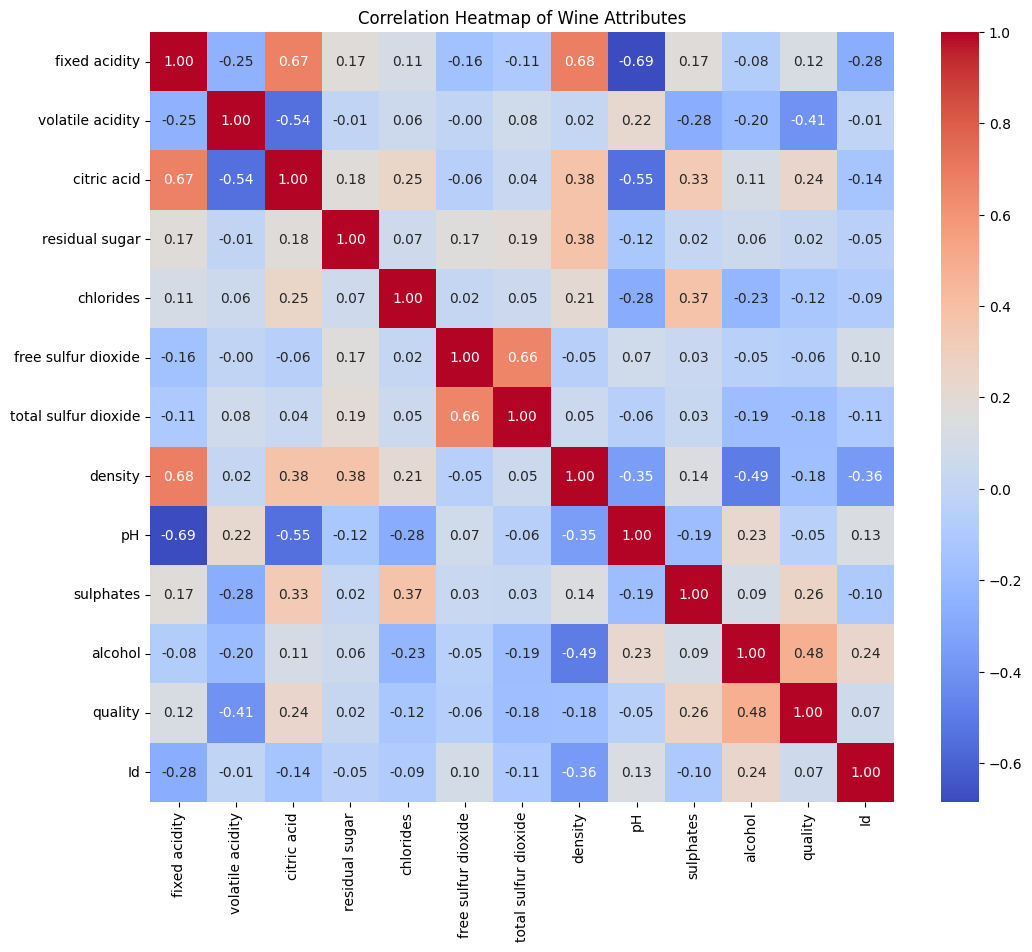

In [26]:
# 5. Visualize this correlation analysis using a heatmap.
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wine Attributes')
plt.show()